In [ ]:
import pandas as pd
import glob 
import numpy as np
import protfasta
from ete4 import Tree
from ete4.treeview import TreeStyle, TextFace, NodeStyle
import tqdm

import seaborn as sns
import matplotlib.pyplot as plt


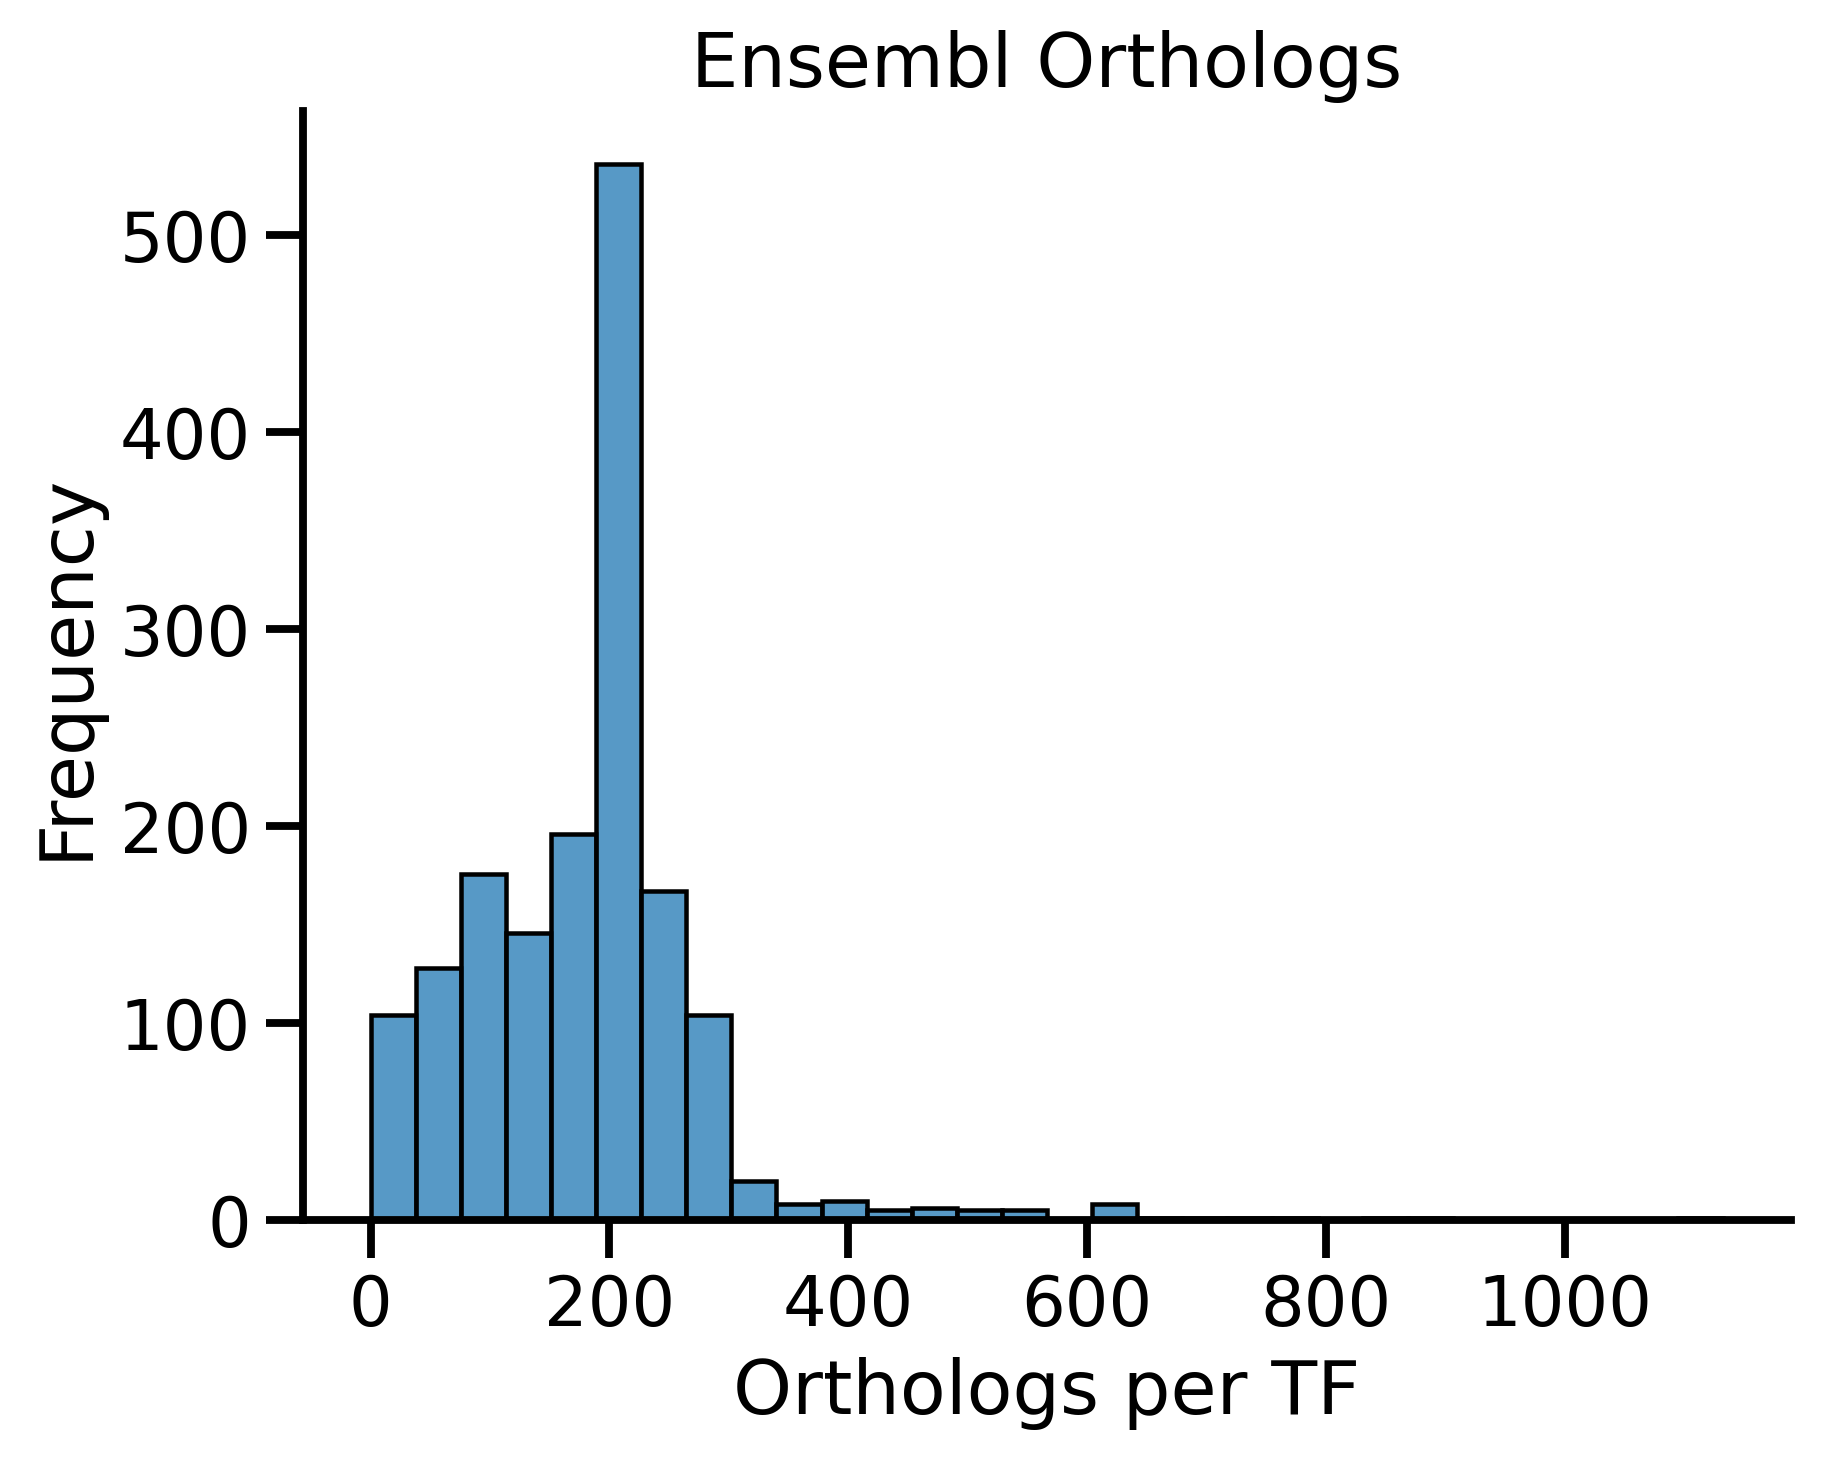

: 

In [ ]:
sns.set_context('talk')

plt.figure(dpi = 300)
# List to store the number of entries per FASTA file
entries_per_fasta = []

# Loop through all FASTA files in the directory
for fasta_file in glob.glob(f"{fasta_dir}/*.fasta"):
    entry_count = 0
    with open(fasta_file, 'r') as file:
        for line in file:
            if line.startswith(">"):  # Check if the line is a header
                entry_count += 1
    entries_per_fasta.append(entry_count)

# Create a histogram using seaborn
sns.histplot(entries_per_fasta, bins=30, kde=False)
plt.title('Ensembl Orthologs')
plt.ylabel('Frequency')
plt.xlabel('Orthologs per TF')
sns.despine()
plt.show()


In [ ]:
fasta_dir = '/Users/sanjanakotha/Desktop/Staller_Lab/SFARI/output/ensembl_orthologs/ortholog_fastas'

# Initialize a dictionary to store species counts
species_count = {}

# Loop through all FASTA files in the directory
for fasta_file in glob.glob(f"{fasta_dir}/*.fasta"):
    with open(fasta_file, 'r') as file:
        for line in file:
            if line.startswith(">"):  # Check if the line is a header
                species = line.strip().split('|')[-1]  # Extract the species from the last '|' symbol
                # Increment the count for the species
                if species in species_count:
                    species_count[species] += 1
                else:
                    species_count[species] = 1

# Print the species counts
print(species_count)

{'homo_sapiens': 1625, 'nomascus_leucogenys': 1482, 'pan_troglodytes': 1651, 'pongo_abelii': 1526, 'pan_paniscus': 1460, 'gorilla_gorilla': 1514, 'ornithorhynchus_anatinus': 1101, 'sarcophilus_harrisii': 1274, 'dasypus_novemcinctus': 1391, 'callithrix_jacchus': 1485, 'cercocebus_atys': 1504, 'macaca_mulatta': 1486, 'macaca_nemestrina': 1495, 'papio_anubis': 1505, 'mus_spretus': 1414, 'vombatus_ursinus': 1422, 'panthera_leo': 1448, 'ochotona_princeps': 1074, 'bos_taurus': 1604, 'jaculus_jaculus': 1236, 'ursus_americanus': 1448, 'panthera_pardus': 1422, 'ovis_aries': 1443, 'urocitellus_parryii': 1375, 'felis_catus': 1373, 'balaenoptera_musculus': 1466, 'pteropus_vampyrus': 1267, 'octodon_degus': 1258, 'ailuropoda_melanoleuca': 1374, 'mesocricetus_auratus': 1262, 'bison_bison_bison': 1276, 'vulpes_vulpes': 1384, 'phocoena_sinus': 1463, 'otolemur_garnettii': 1414, 'mus_pahari': 1364, 'capra_hircus': 1466, 'monodon_monoceros': 1444, 'catagonus_wagneri': 1405, 'rhinopithecus_roxellana': 1502

In [8]:
# Normalize species names
normalized_species_count = {species.replace('_', ' ').title(): count for species, count in species_count.items()}

# Print the normalized species counts
print(normalized_species_count)


{'Homo Sapiens': 1625, 'Nomascus Leucogenys': 1482, 'Pan Troglodytes': 1651, 'Pongo Abelii': 1526, 'Pan Paniscus': 1460, 'Gorilla Gorilla': 1514, 'Ornithorhynchus Anatinus': 1101, 'Sarcophilus Harrisii': 1274, 'Dasypus Novemcinctus': 1391, 'Callithrix Jacchus': 1485, 'Cercocebus Atys': 1504, 'Macaca Mulatta': 1486, 'Macaca Nemestrina': 1495, 'Papio Anubis': 1505, 'Mus Spretus': 1414, 'Vombatus Ursinus': 1422, 'Panthera Leo': 1448, 'Ochotona Princeps': 1074, 'Bos Taurus': 1604, 'Jaculus Jaculus': 1236, 'Ursus Americanus': 1448, 'Panthera Pardus': 1422, 'Ovis Aries': 1443, 'Urocitellus Parryii': 1375, 'Felis Catus': 1373, 'Balaenoptera Musculus': 1466, 'Pteropus Vampyrus': 1267, 'Octodon Degus': 1258, 'Ailuropoda Melanoleuca': 1374, 'Mesocricetus Auratus': 1262, 'Bison Bison Bison': 1276, 'Vulpes Vulpes': 1384, 'Phocoena Sinus': 1463, 'Otolemur Garnettii': 1414, 'Mus Pahari': 1364, 'Capra Hircus': 1466, 'Monodon Monoceros': 1444, 'Catagonus Wagneri': 1405, 'Rhinopithecus Roxellana': 1502

In [14]:
pd.DataFrame(normalized_species_count.keys()).to_csv("../data/ensembl_orthologues_species.txt", header=None, index=None)

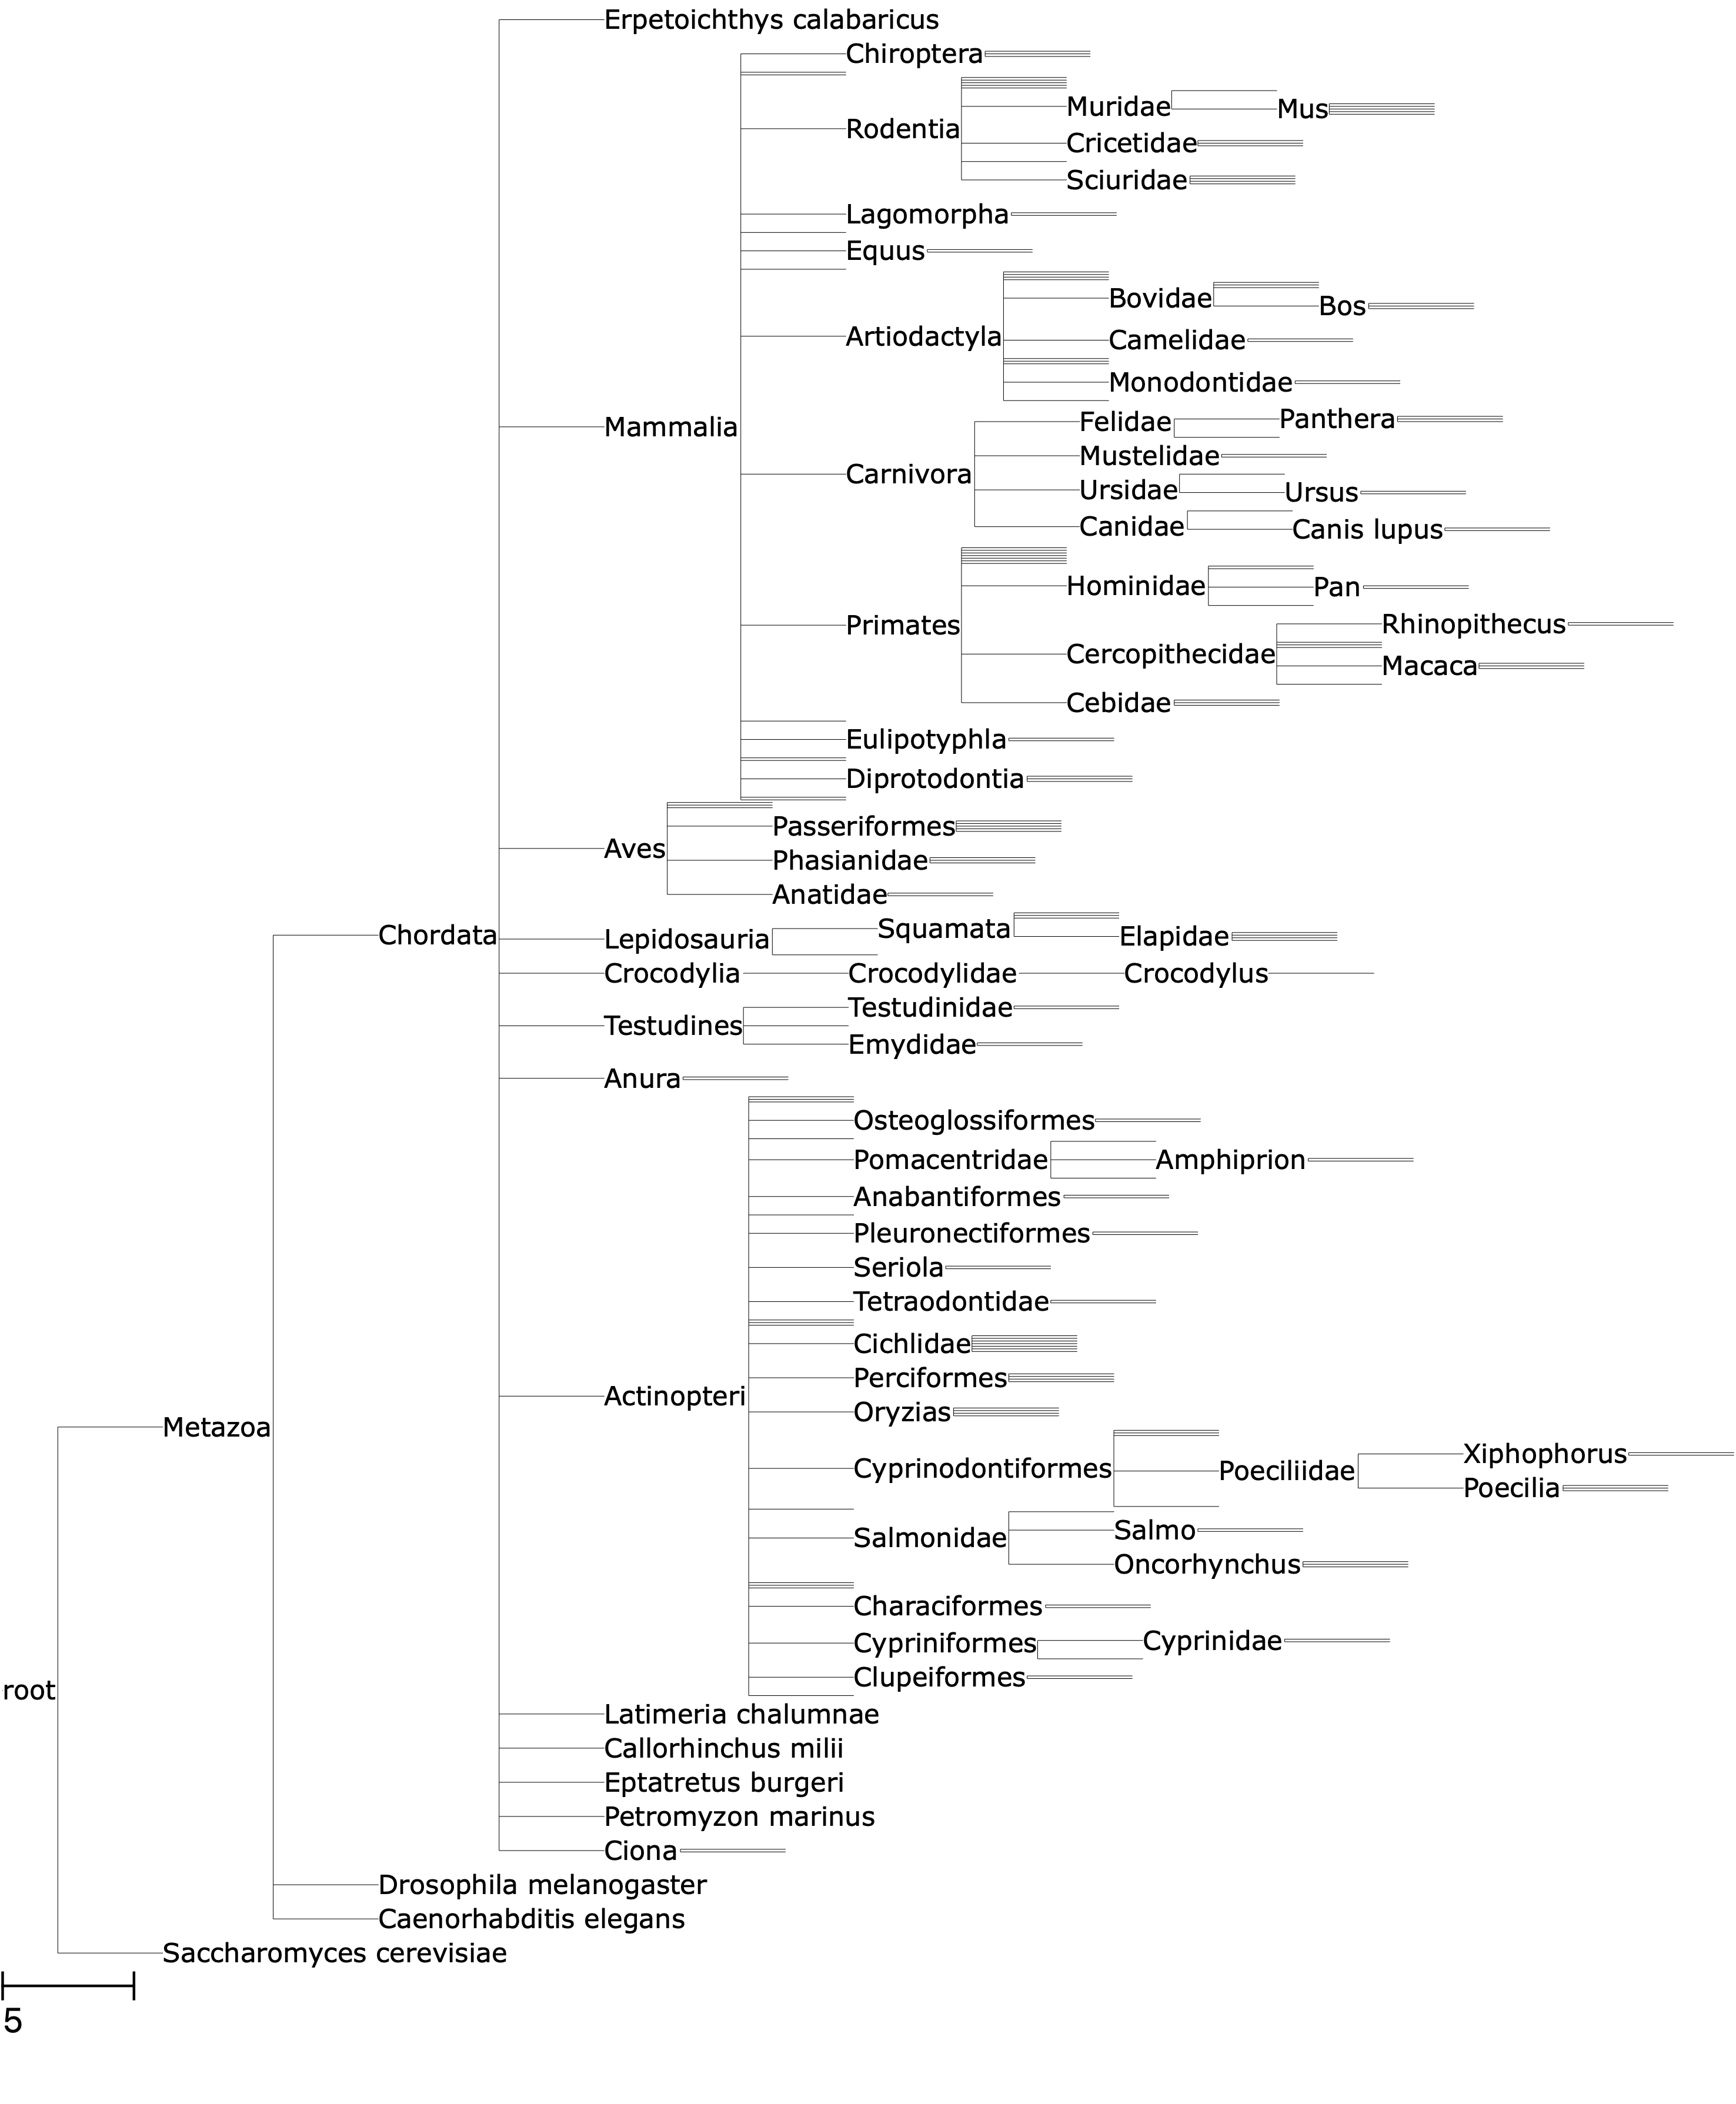

In [94]:
t = Tree(open("../data/ensembl_orthologues_species.phy"), parser=1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
# circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 10
circular_style.show_branch_length = False
circular_style.show_branch_support = False

for node in t.traverse():
    node_from_root = levels_from_root(node)

    if len(node.children) > 0 or node_from_root < 4:
        font_size = 10 #if len(node.children) > 0 else 1  # Font size 20 for nodes with children, else 10
        tf = TextFace(f"{node.name}", fsize=font_size)
        tf.rotation = 0
        # if len(node.children) == 0:
        #     tf.rotation = 0  # Rotate label if the node is not a leaf
        # else:
        #     tf.rotation = -90
        node.add_face(tf, column=0, position="branch-right")

    # Remove blue dots by setting node size to 0
    nstyle = NodeStyle()
    nstyle["size"] = 0
    node.set_style(nstyle)

t.render('%%inline', w=250, units='mm', tree_style=circular_style, dpi=300)


In [24]:
def levels_from_root(node):
    if node.is_root: 
        return 0
    else:
        return 1 + levels_from_root(node.up)

In [33]:
# def total_children(node):
#     if len(node.children) == 0:
#         return 0
#     else:
#         return len(node.children) + sum([total_children(child) for child in node.children])

In [34]:
# total_children_cache = {}

# def total_children_in_data(node):
#     if node in total_children_cache:
#         return total_children_cache[node]

#     if len(node.children) == 0:
#         result = len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
#     else:
#         result = (
#             len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
#             + sum([total_children_in_data(child) for child in node.children])
#         )

#     total_children_cache[node] = result
#     return result


Processing nodes: 268it [00:00, 640862.87it/s]           


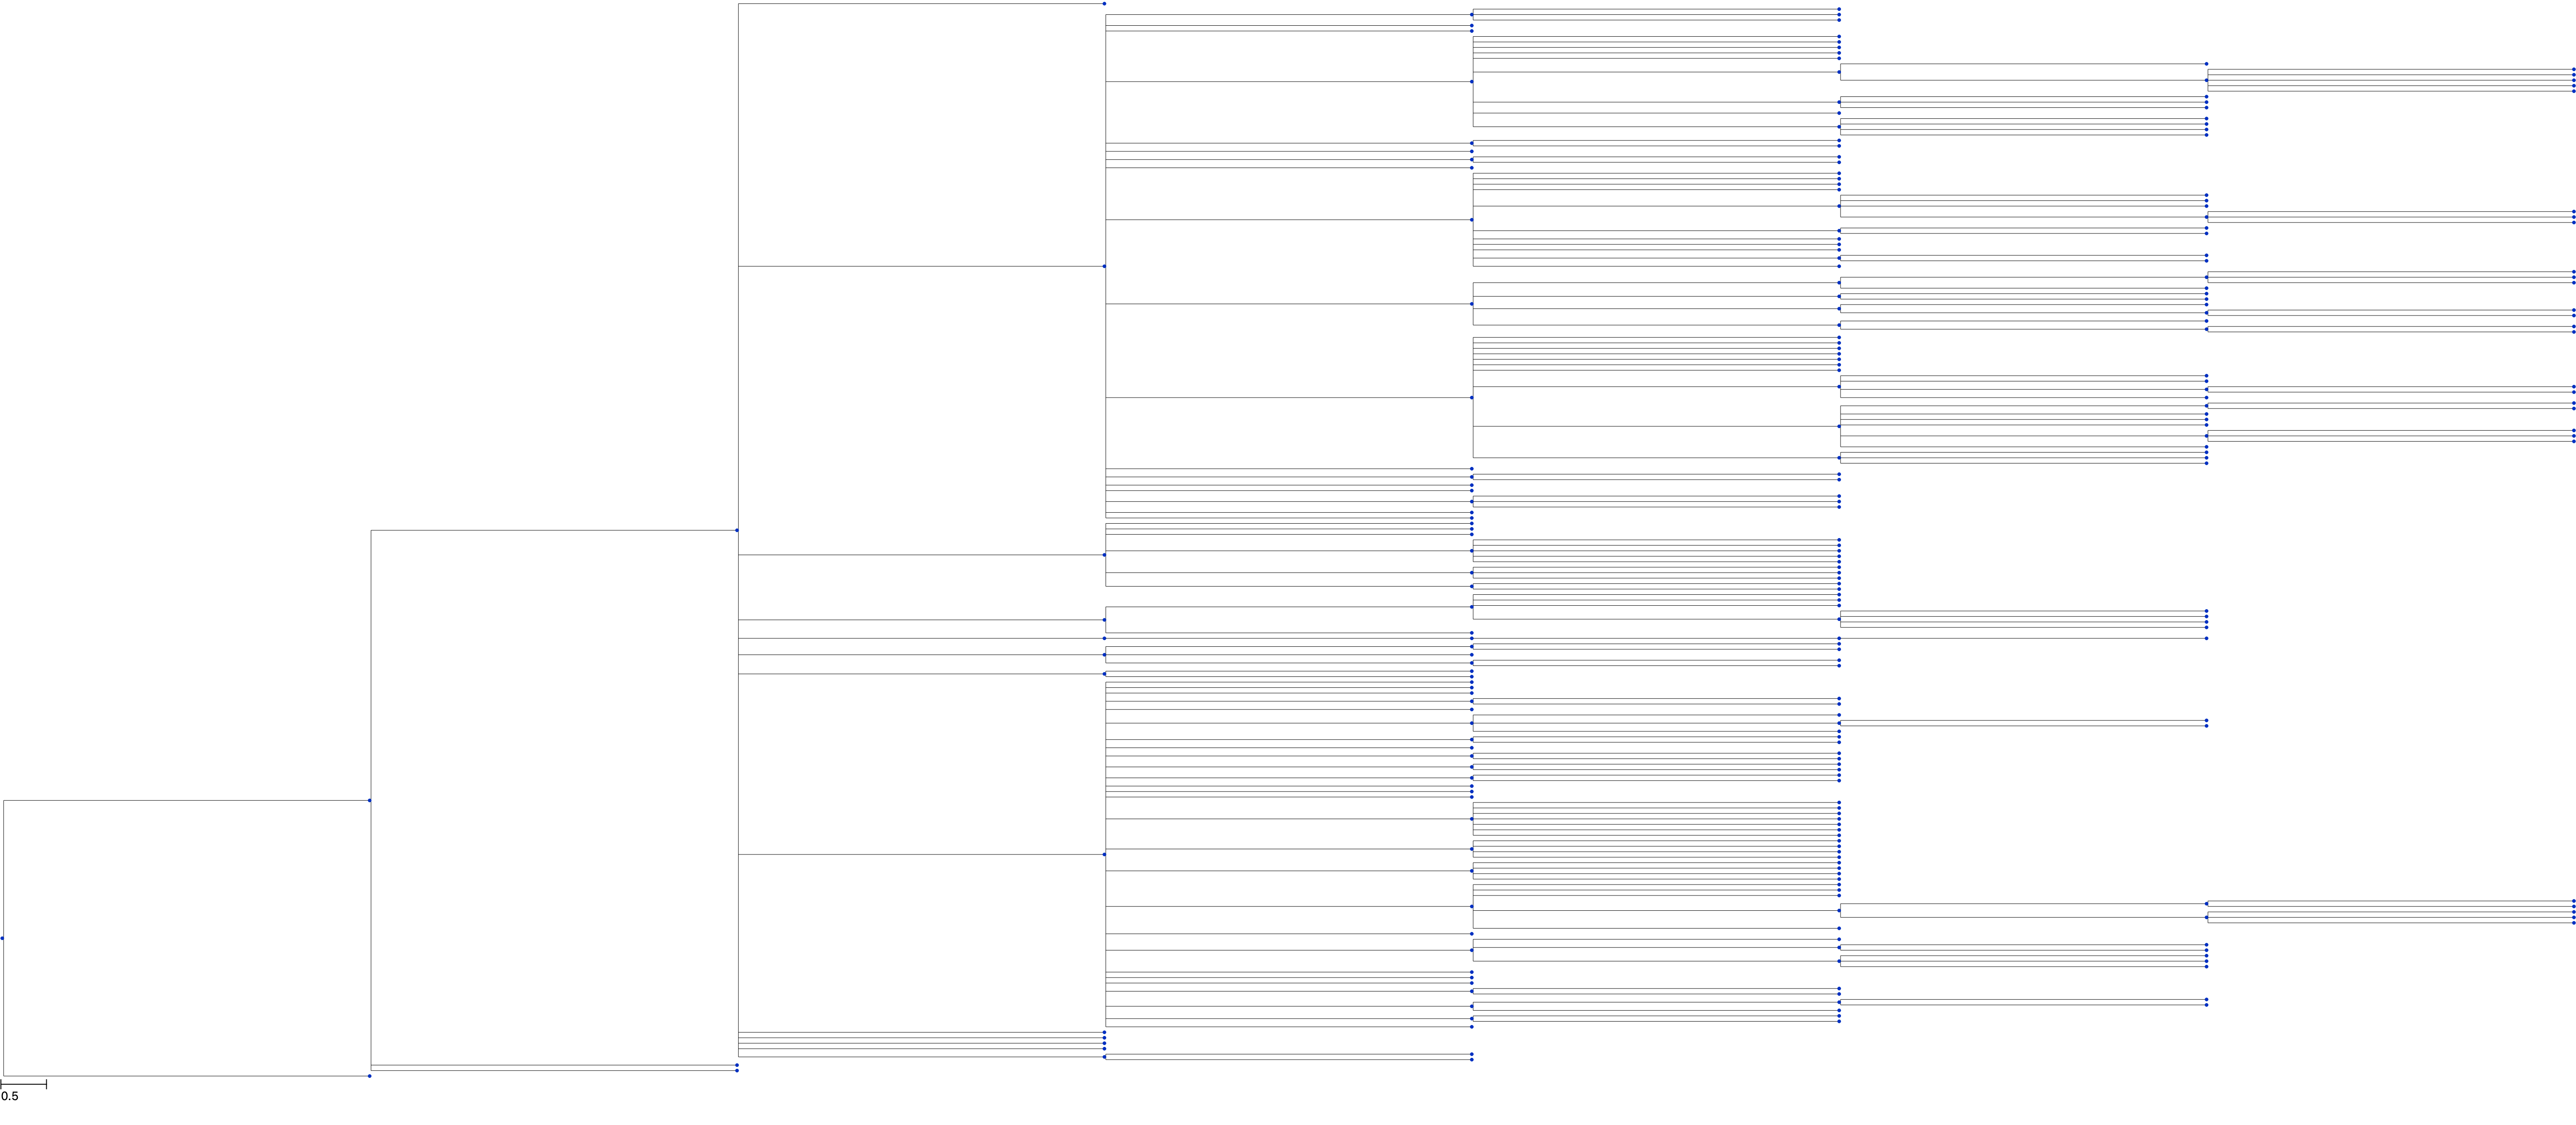

In [43]:
t = Tree(open("../data/ensembl_orthologues_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.mode = 'r'  # draw tree in circular mode
circular_style.scale = 100
circular_style.branch_vertical_margin = 3
circular_style.show_branch_length = False
circular_style.show_branch_support = False
circular_style.show_leaf_name = False

for node in tqdm.tqdm(t.traverse(), total=total_children(t), desc="Processing nodes"):
    node_from_root = levels_from_root(node)
    # node_children = total_children(node)

    if node_from_root < 3:
        tf = TextFace(f"{(str(node.name))[:3]}", fsize = 100)
        # if "vir" in node.name
        #  or "Viruses incertae" in node.name:
        #     print("Skipping labels for viruses:")
        #     print(node.name)
        # if node.name != "root":
        #     size = 500 
        #     tf = TextFace(f"{str(node.name)} n={total_children_in_data(node)}", fsize=size)
        #     tf.rotation = 270
        #     tf.opacity = (total_children_in_data(node) + 25000)/100000
        #     node.add_face(tf, column=0, position="branch-right")

    # nstyle = NodeStyle()
    # nstyle['size'] = 10
    # node.set_style(nstyle)
    # if node.name in set(interpro_species["Organism"]):
    #     size = 20 #min(500, 10 + node_children // 4)  # Cap size to 80
    #     tf = TextFace(f"{(str(node.name))[:3]}", fsize=size)
    #     tf.rotation = 0
    #     node.add_face(tf, column=0, position="branch-right")

t.render('%%inline', w = 500, units='mm', tree_style=circular_style, dpi = 300)
